# Sentiment Analysis with Transformer Encoder

In this notebook, you'll implement a transformer encoder model that makes a prediction about the sentiment of that text, where it is positive or negative. We'll be training the model on a dataset of movie reviews from IMDB that have been labeled either "positive" or "negative".

Since this is text data, words in a sequence, we can use transformer encoder to build a model that doesn't only consider the individual words, but the order they appear in and the context. This leads to a powerful model for making these types of sentiment predictions.

<p float="left">
<img src="https://github.com/udacity/deep-learning-v2-pytorch/blob/master/sentiment-rnn/assets/reviews_ex.png?raw=true" width=40%>


<img src="https://github.com/xjmoffside/ModernAnalytics/blob/main/transformer_sentiment.png?raw=true" width=25%>

</p>

---
### Load in and visualize the data

In [1]:
import numpy as np

# read data from text files
with open('reviews.txt', 'r') as f:
    reviews = f.read()
with open('labels.txt', 'r') as f:
    labels = f.read()

In [2]:
print(reviews[:1000])
print()
print(labels[:20])

bromwell high is a cartoon comedy . it ran at the same time as some other programs about school life  such as  teachers  . my   years in the teaching profession lead me to believe that bromwell high  s satire is much closer to reality than is  teachers  . the scramble to survive financially  the insightful students who can see right through their pathetic teachers  pomp  the pettiness of the whole situation  all remind me of the schools i knew and their students . when i saw the episode in which a student repeatedly tried to burn down the school  i immediately recalled . . . . . . . . . at . . . . . . . . . . high . a classic line inspector i  m here to sack one of your teachers . student welcome to bromwell high . i expect that many adults of my age think that bromwell high is far fetched . what a pity that it isn  t   
story of a man who has unnatural feelings for a pig . starts out with a opening scene that is a terrific example of absurd comedy . a formal orchestra audience is turn

## Data pre-processing

The first step when building a neural network model is getting your data into the proper form to feed into the network. Since we're using embedding layers, we'll need to encode each word with an integer. We'll also want to clean it up a bit.

You can see an example of the reviews data above. Here are the processing steps, we'll want to take:
>* We'll want to get rid of periods and extraneous punctuation.
* Also, you might notice that the reviews are delimited with newline characters `\n`. To deal with those, I'm going to split the text into each review using `\n` as the delimiter.
* Then I can combined all the reviews back together into one big string.

First, let's remove all punctuation. Then get all the text without the newlines and split it into individual words.

In [3]:
from string import punctuation

print(punctuation)

# get rid of punctuation
reviews = reviews.lower() # lowercase, standardize
all_text = ''.join([c for c in reviews if c not in punctuation])

# split by new lines and spaces
reviews_split = all_text.split('\n')
all_text = ' '.join(reviews_split)

# create a list of words
words = all_text.split()

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [4]:
words[:30]

['bromwell',
 'high',
 'is',
 'a',
 'cartoon',
 'comedy',
 'it',
 'ran',
 'at',
 'the',
 'same',
 'time',
 'as',
 'some',
 'other',
 'programs',
 'about',
 'school',
 'life',
 'such',
 'as',
 'teachers',
 'my',
 'years',
 'in',
 'the',
 'teaching',
 'profession',
 'lead',
 'me']

### Encoding the words

The embedding lookup requires that we pass in integers to our network. The easiest way to do this is to create dictionaries that map the words in the vocabulary to integers. Then we can convert each of our reviews into integers so they can be passed into the network.

> **Exercise:** Now you're going to encode the words with integers. Build a dictionary that maps words to integers. Later we're going to pad our input vectors with zeros, so make sure the integers **start at 1, not 0**.
> Also, convert the reviews to integers and store the reviews in a new list called `reviews_ints`.

In [5]:
# feel free to use this import
from collections import Counter
counts = Counter(words)
vocab = sorted(counts, key=counts.get, reverse=True)
# stats about vocabulary
print('Unique words: ', len((vocab)))  # should ~ 74000+
print()

Unique words:  74072



In [6]:
vocab[-10:]

['hoodies',
 'insulation',
 'mwuhahahaa',
 'slagged',
 'bellwood',
 'pressurized',
 'malkovitchesque',
 'muppified',
 'whelk',
 'hued']

In [7]:
## Build a dictionary that maps words to integers
vocab_to_int = {word: ii for ii, word in enumerate(vocab, 1)} # here 1 means the index starts from 1

## use the dict to tokenize each review in reviews_split
## store the tokenized reviews in reviews_ints (which is a list)
reviews_ints = []
for review in reviews_split:
    reviews_ints.append([vocab_to_int[word] for word in review.split()])

**Test your code**

As a text that you've implemented the dictionary correctly, print out the number of unique words in your vocabulary and the contents of the first, tokenized review.

In [8]:
# print tokens in first review
print('Tokenized review: \n', reviews_ints[:1])

Tokenized review: 
 [[21025, 308, 6, 3, 1050, 207, 8, 2138, 32, 1, 171, 57, 15, 49, 81, 5785, 44, 382, 110, 140, 15, 5194, 60, 154, 9, 1, 4975, 5852, 475, 71, 5, 260, 12, 21025, 308, 13, 1978, 6, 74, 2395, 5, 613, 73, 6, 5194, 1, 24103, 5, 1983, 10166, 1, 5786, 1499, 36, 51, 66, 204, 145, 67, 1199, 5194, 19869, 1, 37442, 4, 1, 221, 883, 31, 2988, 71, 4, 1, 5787, 10, 686, 2, 67, 1499, 54, 10, 216, 1, 383, 9, 62, 3, 1406, 3686, 783, 5, 3483, 180, 1, 382, 10, 1212, 13583, 32, 308, 3, 349, 341, 2913, 10, 143, 127, 5, 7690, 30, 4, 129, 5194, 1406, 2326, 5, 21025, 308, 10, 528, 12, 109, 1448, 4, 60, 543, 102, 12, 21025, 308, 6, 227, 4146, 48, 3, 2211, 12, 8, 215, 23]]


### Encoding the labels

Our labels are "positive" or "negative". To use these labels in our network, we need to convert them to 0 and 1.

> **Exercise:** Convert labels from `positive` and `negative` to 1 and 0, respectively, and place those in a new list, `encoded_labels`.

In [9]:
# 1=positive, 0=negative label conversion
labels_split = labels.split('\n')
encoded_labels = np.array([1 if label == 'positive' else 0 for label in labels_split])

### Removing Outliers

As an additional pre-processing step, we want to make sure that our reviews are in good shape for standard processing. That is, our network will expect a standard input text size, and so, we'll want to shape our reviews into a specific length. We'll approach this task in two main steps:

1. Getting rid of extremely long or short reviews; the outliers
2. Padding/truncating the remaining data so that we have reviews of the same length.

Before we pad our review text, we should check for reviews of extremely short or long lengths; outliers that may mess with our training.

In [10]:
# outlier review stats
review_lens = Counter([len(x) for x in reviews_ints])
print("Zero-length reviews: {}".format(review_lens[0])) # review_lens[0] counts the number of reviews with zero length
print("Maximum review length: {}".format(max(review_lens)))

Zero-length reviews: 1
Maximum review length: 2514


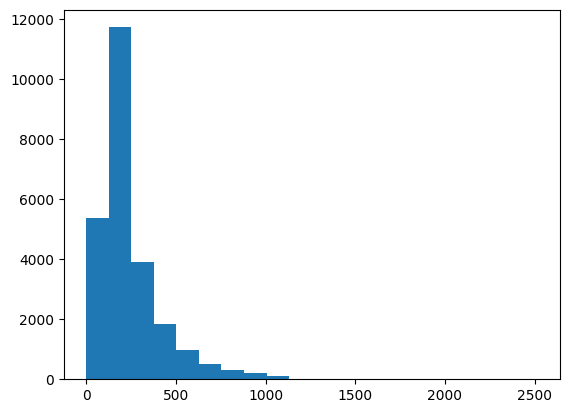

In [11]:
import matplotlib.pyplot as plt
# plot review length statistics
reviews_lens=[len(x) for x in reviews_ints]
plt.hist(reviews_lens,bins=20)
plt.show()

In [12]:
reviews_lens[:20]

[140,
 114,
 447,
 786,
 150,
 146,
 124,
 153,
 121,
 401,
 184,
 104,
 112,
 331,
 346,
 159,
 451,
 68,
 330,
 295]

Okay, a couple issues here. We seem to have one review with zero length. And, the maximum review length is too large for our transformer model. We'll have to remove any super short reviews and truncate super long reviews. This removes outliers and should allow our model to train more efficiently.

> **Exercise:** First, remove *any* reviews with zero length from the `reviews_ints` list and their corresponding label in `encoded_labels`.

In [13]:
print('Number of reviews before removing outliers: ', len(reviews_ints))

## remove any reviews/labels with zero length from the reviews_ints list.

# get indices of any reviews with length 0
non_zero_idx = [ii for ii, review in enumerate(reviews_ints) if len(review) != 0]

# remove 0-length reviews and their labels
reviews_ints = [reviews_ints[ii] for ii in non_zero_idx]
encoded_labels = np.array([encoded_labels[ii] for ii in non_zero_idx])

print('Number of reviews after removing outliers: ', len(reviews_ints))

Number of reviews before removing outliers:  25001
Number of reviews after removing outliers:  25000


---
## Padding sequences

To deal with both short and very long reviews, we'll pad or truncate all our reviews to a specific length. For reviews shorter than some `seq_length`, we'll pad with 0s. For reviews longer than `seq_length`, we can truncate them to the first `seq_length` words.


<img src="https://github.com/udacity/deep-learning-v2-pytorch/blob/master/sentiment-rnn/assets/outliers_padding_ex.png?raw=true" width=40%>



> Define a function that returns an array `features` that contains the padded data, of a standard size, that we'll pass to the network.
* The data should come from `review_ints`, since we want to feed integers to the network.
* Each row should be `seq_length` elements long.
* For reviews shorter than `seq_length` words, **left pad** with 0s. That is, if the review is `['best', 'movie', 'ever']`, `[117, 18, 128]` as integers, the row will look like `[0, 0, 0, ..., 0, 117, 18, 128]`.
* For reviews longer than `seq_length`, use only the first `seq_length` words as the feature vector.

As a small example, if the `seq_length=10` and an input review is:
```
[117, 18, 128]
```
The resultant, padded sequence should be:

```
[0, 0, 0, 0, 0, 0, 0, 117, 18, 128]
```

**Your final `features` array should be a 2D array, with as many rows as there are reviews, and as many columns as the specified `seq_length`.**

This isn't trivial and there are a bunch of ways to do this. But, if you're going to be building your own deep learning networks, you're going to have to get used to preparing your data.

In [14]:
def pad_features(reviews_ints, seq_length):
    ''' Return features of review_ints, where each review is padded with 0's
        or truncated to the input seq_length.
    '''

    # getting the correct rows x cols shape
    features = np.zeros((len(reviews_ints), seq_length), dtype=int)

    # for each review, I grab that review and put it into features
    for i, row in enumerate(reviews_ints):
        features[i, -len(row):] = np.array(row)[:seq_length]

    return features

In [15]:
# Test your implementation!

seq_length = 400

features = pad_features(reviews_ints, seq_length=seq_length)

## test statements - do not change - ##
assert len(features)==len(reviews_ints), "Your features should have as many rows as reviews."
assert len(features[0])==seq_length, "Each feature row should contain seq_length values."

# print first 10 values of the first 30 batches
print(features[:30,:10])

[[    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [22382    42 46418    15   706 17139  3389    47    77    35]
 [ 4505   505    15     3  3342   162  8312  1652     6  4819]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [   54    10    14   116    60   798   552    71   364     5]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     0

## Training, Validation, Test

With our data in nice shape, we'll split it into training, validation, and test sets.

> **Exercise:** Create the training, validation, and test sets.
* You'll need to create sets for the features and the labels, `train_x` and `train_y`, for example.
* Define a split fraction, `split_frac` as the fraction of data to **keep** in the training set. Usually this is set to 0.8 or 0.9.
* Whatever data is left will be split in half to create the validation and *testing* data.

In [16]:
split_frac = 0.8

## split data into training, validation, and test data (features and labels, x and y)

split_idx = int(len(features)*split_frac)
train_x, remaining_x = features[:split_idx], features[split_idx:]
train_y, remaining_y = encoded_labels[:split_idx], encoded_labels[split_idx:]

test_idx = int(len(remaining_x)*0.5)
val_x, test_x = remaining_x[:test_idx], remaining_x[test_idx:]
val_y, test_y = remaining_y[:test_idx], remaining_y[test_idx:]

## print out the shapes of your resultant feature data
print("\t\t\tFeature Shapes:")
print("Train set: \t\t{}".format(train_x.shape),
      "\nValidation set: \t{}".format(val_x.shape),
      "\nTest set: \t\t{}".format(test_x.shape))

			Feature Shapes:
Train set: 		(20000, 400) 
Validation set: 	(2500, 400) 
Test set: 		(2500, 400)


**Check your work**

With train, validation, and test fractions equal to 0.8, 0.1, 0.1, respectively, the final, feature data shapes should look like:
```
                    Feature Shapes:
Train set: 		 (20000, 400)
Validation set: 	(2500, 400)
Test set: 		  (2500, 400)
```

---
## DataLoaders and Batching


After creating training, test, and validation data, we can create DataLoaders for this data by following two steps:
1. Create a known format for accessing our data, using [TensorDataset](https://pytorch.org/docs/stable/data.html#) which takes in an input set of data and a target set of data with the same first dimension, and creates a dataset.
2. Create DataLoaders and batch our training, validation, and test Tensor datasets.

```
train_data = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
train_loader = DataLoader(train_data, batch_size=batch_size)
```

This is an alternative to creating a generator function for batching our data into full batches.

In [17]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# create Tensor datasets
train_data = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
valid_data = TensorDataset(torch.from_numpy(val_x), torch.from_numpy(val_y))
test_data = TensorDataset(torch.from_numpy(test_x), torch.from_numpy(test_y))

# dataloaders
batch_size = 32

# make sure the SHUFFLE your training data
# drop_last=True will drop the last batch if the size is less than the given batch_size
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size,  drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=True, batch_size=batch_size, drop_last=True)

In [18]:
# obtain one batch of training data
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x)
print()
print('Sample label size: ', sample_y.size()) # batch_size
print('Sample label: \n', sample_y)

Sample input size:  torch.Size([32, 400])
Sample input: 
 tensor([[   0,    0,    0,  ...,    1,  399, 3444],
        [   0,    0,    0,  ...,   28,  124,  108],
        [   0,    0,    0,  ...,   18,  179, 1703],
        ...,
        [   0,    0,    0,  ..., 4811,    7,    7],
        [   0,    0,    0,  ...,   23,  327,  523],
        [   0,    0,    0,  ...,  217,  231,  326]])

Sample label size:  torch.Size([32])
Sample label: 
 tensor([1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 0, 0, 1, 0, 0, 1, 0])


In [19]:
# First checking if GPU is available
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [20]:
import torch.nn as nn

---
## Define embedding layer with positional encoding

The original [``attention is all your need'' paper](https://arxiv.org/abs/1706.03762) uses a clever trick of sine/cosine waves to encode word positions. Here, we will do something simpler and more effective: we will represent the position of a word in an input sequence as *i* ranges from 0, 1, ..., *seq_len-1*. Then we use the embeding layer to map each integer value to a vector of dimension `embed_dim`.

We will define a custom embedding layer with weights initialized as zero.

In [21]:
class ZeroEmbedding(nn.Embedding):
    """
    Used for biases.
    """

    def reset_parameters(self):
        """
        Initialize parameters.
        """

        self.weight.data.zero_()
        if self.padding_idx is not None:
            self.weight.data[self.padding_idx].fill_(0.0)

We will then use the `ZeroEmbedding` layer to encode position index.

In [22]:
class PositionalEmbedding(nn.Module):
    """
    PositionalEmbedding is a class for adding positional embeddings to token embeddings.

    Args:
        sequence_length (int): The maximum sequence length.
        input_dim (int): The dimension of input token embeddings (vocabulary size)
        output_dim (int): The dimension of output positional embeddings.

    Attributes:
        token_embeddings (nn.Embedding): The token embedding layer.
        position_embeddings (nn.Embedding): The positional embedding layer.
        sequence_length (int): The maximum sequence length.
    """

    def __init__(self, sequence_length, input_dim, output_dim):
        super(PositionalEmbedding, self).__init__()
        #TODO: add embedding layers to map words to vectors
        self.token_embeddings = nn.Embedding(input_dim, output_dim)
        #TODO: add embedding layers to map position index to vectors
        self.position_embeddings = ZeroEmbedding(sequence_length, output_dim)
        self.sequence_length = sequence_length

    def forward(self, inputs):
        """
        Forward pass of the PositionalEmbedding.

        Args:
            inputs (torch.Tensor): The input tensor of token indices.

        Returns:
            torch.Tensor: The output tensor with positional embeddings added to token embeddings.
        """
        length = inputs.size(-1)
        device = inputs.device
        #TODO: compute the position index 0, 1, ..., seq_len -1
        positions = torch.arange(0, self.sequence_length).unsqueeze(0).to(device) # here we add the batch_size as first dim
        #TODO: compute the word embeddings
        embedded_tokens = self.token_embeddings(inputs)
        #TODO: compute the positional embeddings
        embedded_positions = self.position_embeddings(positions)
        #TODO: return the final embeddings
        return embedded_tokens + embedded_positions   # here the first dim of embedded_positions will be broadcasted to match the batch size

Let's take a batch and check the embedding layer works as we expected.

In [23]:
# Hyperparameters for embedding layers
vocab_size = len(vocab_to_int)+1  # +1 for the 0 padding
embed_dim = 512

In [24]:
# Define the embedding layer with positional information
input_embed=PositionalEmbedding(seq_length, vocab_size, embed_dim)

In [25]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)
sample_x.shape, sample_y.shape

(torch.Size([32, 400]), torch.Size([32]))

In [26]:
sample_emd=input_embed(sample_x)
sample_emd.shape

torch.Size([32, 400, 512])

This is great! We see that `sample_emd.shape` has shape `[batch_size, seq_len, embed_dim]`.

---
## Build Transformer encoder

Below is the architecture of the transformer encoder proposed in the [``attention is all your need'' paper](https://arxiv.org/abs/1706.03762).

<img src="https://github.com/xjmoffside/ModernAnalytics/blob/main/transformer_encoder.png?raw=true" width=20%>


For the multi-head attention layer, we use class [`nn.MultiheadAttention`](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html?highlight=nn+multiheadattention#torch.nn.MultiheadAttention):

 > `torch.nn.MultiheadAttention(embed_dim, num_heads,batch_first=False)`

  - `embed_dim`: The dimension of the input embeddings and output embeddings.
  - `num_heads`: The number of attention heads in the multi-head attention layer.

  - `batch_first=True`: The input has dimension `(batch_size, seq_len, embed_dim)`

In [27]:
class TransformerEncoder(nn.Module):
    """
    TransformerEncoder is a class representing a Transformer encoder block.

    Args:
        embed_dim (int): The dimension of the input embeddings and output embeddings.
        dense_dim (int): The dimension of the intermediate dense layer within the block.
        num_heads (int): The number of attention heads in the multi-head attention layer.

    Attributes:
        embed_dim (int): The dimension of the input embeddings and output embeddings.
        dense_dim (int): The dimension of the intermediate dense layer within the block.
        num_heads (int): The number of attention heads in the multi-head attention layer.
        attention (nn.MultiheadAttention): The multi-head attention layer.
        dense_proj (nn.Sequential): The sequential dense projection layers.
        layernorm_1 (nn.LayerNorm): The layer normalization after the attention layer.
        layernorm_2 (nn.LayerNorm): The layer normalization after the dense projection.
    """

    def __init__(self, embed_dim, dense_dim, num_heads):
        super(TransformerEncoder, self).__init__()
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        #TODO: Define multihead attention layer
        #Input and output both have size (batch_size, seq_len, embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads,batch_first=True)


        #TODO: define a two-layer Feed-forward network with hidden layer size dense_dim and output layer size embed_dim
        self.dense_proj = nn.Sequential(
            nn.Linear(embed_dim, dense_dim),
            nn.ReLU(),
            nn.Linear(dense_dim, embed_dim)
        )
        #TODO: define two layer normalization layers
        self.layernorm_1 = nn.LayerNorm(embed_dim)
        self.layernorm_2 = nn.LayerNorm(embed_dim)

    def forward(self, inputs):
        """
        Forward pass of the TransformerEncoder block.

        Args:
            inputs (torch.Tensor): The input tensor of shape (batch_size, seq_len, embed_dim).

        Returns:
            torch.Tensor: The output tensor of shape ( batch_size,seq_len, embed_dim).
        """
        #TODO: pass inputs through the multihead attention layer
        attention_output, _ = self.attention(query=inputs, key=inputs, value=inputs)
        #TODO: pass the attention output through the add+normalization layer
        proj_input = self.layernorm_1(inputs + attention_output)
        #TODO: pass through the feed-forward network
        proj_output = self.dense_proj(proj_input)
        #TODO: pass through another add+normalization layer and output
        return self.layernorm_2(proj_input + proj_output)

---
## Use the Transformer encoder for text classification

Note that the output of the transformer encoder has dimension `(batch_size, seq_len, embed_dim)`. To use this output for sentiment classification, we reduce the output
to a vector of dimension `(batch_size, 1, embed_dim)` by taking the maximum along the `seq_len` axis.

After that, we add a dropout layer and a fully-connected layer to output a vector of dimension `(batch_size,1)`, followed by the sigmod layer.

<img src="https://github.com/xjmoffside/ModernAnalytics/blob/main/transformer_sentiment.png?raw=true" width=25%>

In [28]:
class TransformerEncoderModel(nn.Module):
    """
    TransformerEncoderModel is a class representing a text classification model using Transformer encoder with positional embeddings.

    Args:
        vocab_size (int): The size of the vocabulary.
        embed_dim (int): The dimension of the input embeddings and output embeddings.
        num_heads (int): The number of attention heads in the Transformer encoder.
        dense_dim (int): The dimension of the intermediate dense layer.
        sequence_length (int): The maximum sequence length for positional embeddings.

    Attributes:
        embedding (PositionalEmbedding): The positional embedding layer.
        transformer_encoder (TransformerEncoder): The Transformer encoder block.
        global_max_pooling (nn.AdaptiveMaxPool1d): The global max-pooling layer.
        dropout (nn.Dropout): The dropout layer.
        fc (nn.Linear): The fully connected layer for classification.
        sigmoid (nn.Sigmoid): The sigmoid activation function for binary classification.
    """

    def __init__(self, vocab_size, embed_dim, num_heads, dense_dim, sequence_length):
        super(TransformerEncoderModel, self).__init__()

        #TODO: add embedding layer that maps word to vectors
        self.embedding = PositionalEmbedding(sequence_length, vocab_size, embed_dim)

        #TODO: add transformer encoder
        self.transformer_encoder = TransformerEncoder(embed_dim, dense_dim, num_heads)

        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(embed_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        """
        Forward pass of the TransformerEncoderModel for text classification.

        Args:
            inputs (torch.Tensor): The input tensor of shape (batch_size, seq_len).
            mask (torch.Tensor, optional): The attention mask tensor of shape (batch_size, seq_len).
                Defaults to None.

        Returns:
            torch.Tensor: The output tensor with sigmoid activation for binary classification.
        """
        x = self.embedding(inputs)
        x = self.transformer_encoder(x)        # x has shape (Batch, Seq_Len, Embed_dim)
        x,_ = torch.max(x, dim=1)              # x has shape (Batch, Embd_dim)
        x = self.dropout(x)                    # pass dropout layer
        x = self.fc(x)                         # pass a linear layer
        return self.sigmoid(x)                 # pass sigmoid activation


In [29]:
# Model
num_heads = 2
dense_dim = 1024
model = TransformerEncoderModel(vocab_size, embed_dim, num_heads, dense_dim, seq_length)
print(model)

TransformerEncoderModel(
  (embedding): PositionalEmbedding(
    (token_embeddings): Embedding(74073, 512)
    (position_embeddings): ZeroEmbedding(400, 512)
  )
  (transformer_encoder): TransformerEncoder(
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (dense_proj): Sequential(
      (0): Linear(in_features=512, out_features=1024, bias=True)
      (1): ReLU()
      (2): Linear(in_features=1024, out_features=512, bias=True)
    )
    (layernorm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (layernorm_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Let's take a batch and check the transformer model works as we expected.

In [30]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)
sample_output=model(sample_x)

In [32]:
sample_x.shape, sample_y.shape

(torch.Size([32, 400]), torch.Size([32]))

In [33]:
print('Sample input size: ', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x)
print()
print('Sample label size: ', sample_output.size()) # batch_size
print('Sample label: \n', sample_output)

Sample input size:  torch.Size([32, 400])
Sample input: 
 tensor([[   46,    21,   139,  ..., 10685,   854,     4],
        [    0,     0,     0,  ...,   121,     5,   772],
        [    0,     0,     0,  ...,  1016,   116,   326],
        ...,
        [    0,     0,     0,  ...,    87,     8,   619],
        [    0,     0,     0,  ...,    29,    50,   700],
        [    0,     0,     0,  ...,    52,    73,   124]])

Sample label size:  torch.Size([32, 1])
Sample label: 
 tensor([[0.0502],
        [0.0200],
        [0.2052],
        [0.0516],
        [0.0479],
        [0.0918],
        [0.0341],
        [0.0746],
        [0.1743],
        [0.0683],
        [0.0379],
        [0.0318],
        [0.0844],
        [0.0612],
        [0.0555],
        [0.0320],
        [0.0394],
        [0.0367],
        [0.1251],
        [0.1503],
        [0.0520],
        [0.0586],
        [0.0614],
        [0.1282],
        [0.0792],
        [0.0883],
        [0.0284],
        [0.0521],
        [0.0261],
 

### Training and evaluating the Transformer encoder based model

In [ ]:
import torch.optim as optim

Note that the output is a probability, so we use Binary Cross Entropy loss [`nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html).

In [ ]:
criterion = nn.BCELoss()

In [ ]:
# move model to GPU, if available
if(train_on_gpu):
    model.cuda()

Now, we are ready to train the transformer encoder model. Note that in each pass, we need to compute the attention score for every pairs of words in the input sequence. Thus, the time complexity for one pass is quadratic in `seq_len`. Thus, we need to select `seq_len` to be not too long, for efficient training of the transformer model.

In [ ]:
def train(model, train_loader, val_loader, num_epochs=10):
    optimizer = torch.optim.Adam(model.parameters())
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        ### Traing Loop ####
        #0. Loop through all the training batches
        for inputs, labels in train_loader:
            if(train_on_gpu):
              inputs,labels = inputs.cuda(), labels.cuda()

            #1. Compute the output
            outputs = model(inputs).squeeze(1)
            #2. Compute the loss
            loss = criterion(outputs, labels.float())
            #3. Zero out gradients
            optimizer.zero_grad()
            #4. Compute new gradients, by backward propagation
            loss.backward()
            #5. Update the model parameters
            optimizer.step()

            total_loss += loss.item()
        # Print training loss for this epoch
        print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {total_loss / len(train_loader)}")

        ### Validation Loop ###
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                if(train_on_gpu):
                  inputs, labels= inputs.cuda(), labels.cuda()
                outputs = model(inputs).squeeze(1)
                predicted = (outputs >= 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"Epoch {epoch + 1}/{num_epochs}, Validation Accuracy: {val_acc:.2f}%")

In [ ]:
# Train the model
# starts to overfit, when num_epochs ~ 2
train(model, train_loader, valid_loader, num_epochs=2)

Epoch 1/2, Training Loss: 0.4707436850786209
Epoch 1/2, Validation Accuracy: 84.33%
Epoch 2/2, Training Loss: 0.3674736431360245
Epoch 2/2, Validation Accuracy: 83.05%


The transformer model starts to overfit after 2 epochs. Now, we are ready to test our transformer model.

In [ ]:
# Evaluate the model on the test dataset
test_losses = [] # track loss
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        if(train_on_gpu):
          inputs, labels = inputs.cuda(), labels.cuda()
        outputs = model(inputs).squeeze()
        predicted = (outputs >= 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        test_loss = criterion(outputs, labels.float())
        test_losses.append(test_loss.item())
print("Test loss: {:.3f}".format(np.mean(test_losses)))
test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test loss: 0.378
Test Accuracy: 83.05%


We can see that we achieved test accurracy around 83% - better than the LSTM model.

## Inference on a test review

You can change this test_review to any text that you want. Read it and think: is it pos or neg? Then see if your model predicts correctly!
    
> **Exercise:** Write a `predict` function that takes in a trained net, a plain text_review, and a sequence length, and prints out a custom statement for a positive or negative review!
* You can use any functions that you've already defined or define any helper functions you want to complete `predict`, but it should just take in a trained net, a text review, and a sequence length.


In [ ]:
# negative test review
test_review_neg = 'The worst movie I have seen; acting was terrible and I want my money back. This movie had bad acting and the dialogue was slow.'


In [ ]:
from string import punctuation

def tokenize_review(test_review):
    test_review = test_review.lower() # lowercase
    # get rid of punctuation
    test_text = ''.join([c for c in test_review if c not in punctuation])

    # splitting by spaces
    test_words = test_text.split()

    # tokens
    test_ints = []
    test_ints.append([vocab_to_int.get(word, 0) for word in test_words])

    return test_ints

# test code and generate tokenized review
test_ints = tokenize_review(test_review_neg)
print(test_ints)

[[1, 247, 18, 10, 28, 108, 113, 14, 388, 2, 10, 181, 60, 273, 144, 11, 18, 68, 76, 113, 2, 1, 410, 14, 539]]


In [ ]:
# test sequence padding
features = pad_features(test_ints, seq_length)

print(features)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0 

In [ ]:
# test conversion to tensor and pass into your model
feature_tensor = torch.from_numpy(features)
print(feature_tensor.size())

torch.Size([1, 400])


In [ ]:
def predict(net, test_review, sequence_length=400):

    net.eval()

    # tokenize review
    test_ints = tokenize_review(test_review)

    # pad tokenized sequence
    seq_length=sequence_length
    features = pad_features(test_ints, seq_length)

    # convert to tensor to pass into your model
    feature_tensor = torch.from_numpy(features)

    batch_size = feature_tensor.size(0)



    if(train_on_gpu):
        feature_tensor = feature_tensor.cuda()

    # get the output from the model
    output= net(feature_tensor)

    # convert output probabilities to predicted class (0 or 1)
    pred = torch.round(output.squeeze())
    # printing output value, before rounding
    print('Prediction value, pre-rounding: {:.6f}'.format(output.item()))

    # print custom response
    if(pred.item()==1):
        print("Positive review detected!")
    else:
        print("Negative review detected.")


In [ ]:
# positive test review
test_review_pos = 'This movie had the best acting and the dialogue was so good. I loved it.'

In [ ]:
# call function
predict(model, test_review_neg, seq_length)

Prediction value, pre-rounding: 0.003335
Negative review detected.


## Try out test_reviews of your own!

Now that you have a trained model and a predict function, you can pass in _any_ kind of text and this model will predict whether the text has a positive or negative sentiment. Push this model to its limits and try to find what words it associates with positive or negative.

In [ ]:
# positive test review
# The Hunger Games: The Ballad of Songbirds & Snakes (2023)
test_review_pos = 'The Hunger Games: The Ballad Of Songbirds & Snakes is the perfect masterpiece haunting origin tale \
                    showing the downfall of president snow. What a masterful job at taking the book and adapting it to the screen. \
                    The cinematography is excellent.'
predict(model, test_review_pos, seq_length)

Prediction value, pre-rounding: 0.956132
Positive review detected!


## Well Done!

<img src="https://video.udacity-data.com/topher/2018/November/5be21b06_dancing-beemo/dancing-beemo.gif?raw=true" width=40%>